In [2]:
from google.colab import files
uploaded = files.upload()

In [3]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [8]:
df.drop('customerID', axis=1, inplace=True)

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_12740/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [12]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
df.head()
df.shape

(7043, 31)

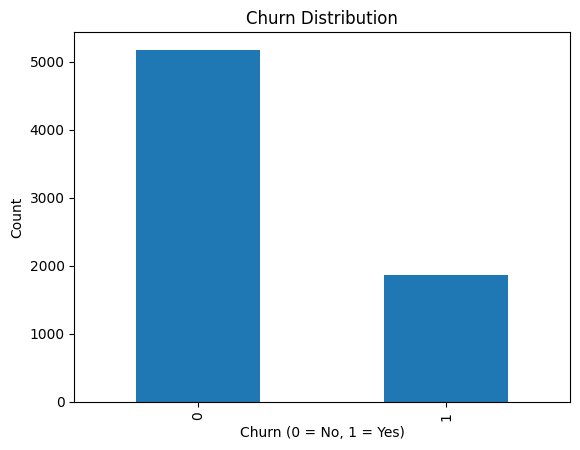

In [15]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

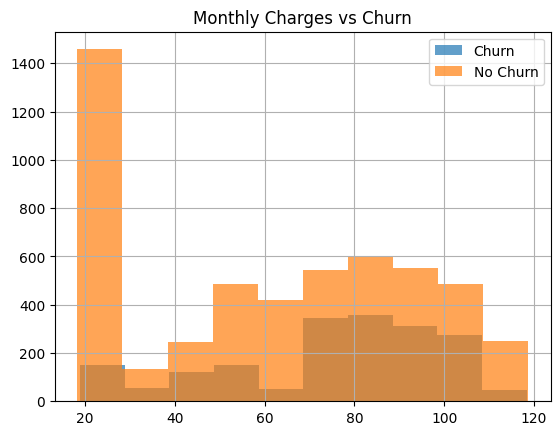

In [16]:
df[df['Churn']==1]['MonthlyCharges'].hist(alpha=0.7)
df[df['Churn']==0]['MonthlyCharges'].hist(alpha=0.7)

plt.legend(['Churn', 'No Churn'])
plt.title("Monthly Charges vs Churn")
plt.show()

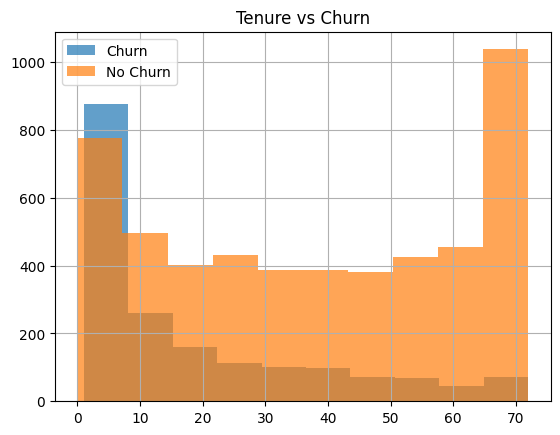

In [17]:
df[df['Churn']==1]['tenure'].hist(alpha=0.7)
df[df['Churn']==0]['tenure'].hist(alpha=0.7)

plt.legend(['Churn', 'No Churn'])
plt.title("Tenure vs Churn")
plt.show()

In [ ]:
#phase-5 - model building

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.801277501774308

Confusion Matrix:
 [[949  87]
 [193 180]]

Report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
#“I used Random Forest because it handles categorical data well after encoding, reduces overfitting using ensemble learning, and performs well on structured datasets.”

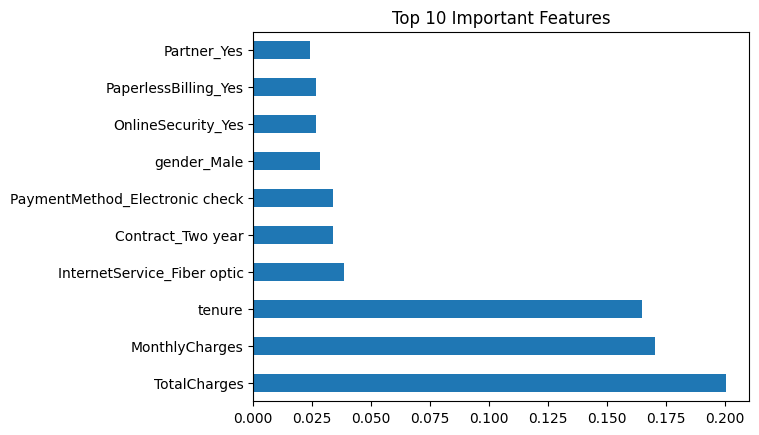

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [23]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.3 MB/s eta 0:00:00


In [48]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


st.title("📊 Telecom Churn Dashboard")

# Load data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Preprocessing
df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Fix NaN issue
df.dropna(subset=['Churn'], inplace=True)

# Encode
df = pd.get_dummies(df, drop_first=True)

# Show data
st.subheader("Dataset Preview")
st.dataframe(df.head())

# Churn distribution
st.subheader("Churn Distribution")
st.bar_chart(df['Churn'].value_counts())

# Split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Monthly Charges vs Churn
st.subheader("Monthly Charges Distribution")
fig, ax = plt.subplots()
df[df['Churn']==1]['MonthlyCharges'].hist(alpha=0.7)
df[df['Churn']==0]['MonthlyCharges'].hist(alpha=0.7)
ax.legend(['Churn', 'No Churn'])
st.pyplot(fig)

# Tenure vs Churn
st.subheader("Tenure Distribution")
fig, ax = plt.subplots()
df[df['Churn']==1]['tenure'].hist(alpha=0.7)
df[df['Churn']==0]['tenure'].hist(alpha=0.7)
ax.legend(['Churn', 'No Churn'])
st.pyplot(fig)

# ================= UI =================

st.subheader("📌 Model Performance")

accuracy = accuracy_score(y_test, y_pred)
st.write(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
st.subheader("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
st.pyplot(fig)

# ================= Feature Importance =================

st.subheader("🔥 Top 10 Important Features")

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importances.nlargest(10)

fig, ax = plt.subplots()
top_features.sort_values().plot(kind='barh', ax=ax)
st.pyplot(fig)




Overwriting app.py


In [31]:
# %%writefile app.py
# import streamlit as st
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, confusion_matrix

# st.title("📊 Telecom Churn Prediction Dashboard")

# # Load data
# df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# # Preprocessing
# df.drop('customerID', axis=1, inplace=True)
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
# df = pd.get_dummies(df, drop_first=True)

# # Split
# X = df.drop('Churn', axis=1)
# y = df['Churn']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # Model
# model = RandomForestClassifier()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# # ================= UI =================

# st.subheader("📌 Model Performance")

# accuracy = accuracy_score(y_test, y_pred)
# st.write(f"Accuracy: {accuracy:.2f}")

# # Confusion Matrix
# st.subheader("Confusion Matrix")
# cm = confusion_matrix(y_test, y_pred)
# fig, ax = plt.subplots()
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
# ax.set_xlabel('Predicted')
# ax.set_ylabel('Actual')
# ax.set_title('Confusion Matrix')
# st.pyplot(fig)

# # ================= Feature Importance =================

# st.subheader("🔥 Top 10 Important Features")

# feature_importances = pd.Series(model.feature_importances_, index=X.columns)
# top_features = feature_importances.nlargest(10)

# fig, ax = plt.subplots()
# top_features.sort_values().plot(kind='barh', ax=ax)
# st.pyplot(fig)

# # ================= Data Preview =================

# st.subheader("Dataset Preview")
# st.dataframe(df.head())

# # ================= Churn Distribution =================

# st.subheader("Churn Distribution")
# st.bar_chart(df['Churn'].value_counts())

Overwriting app.py


In [49]:
#2XfeNsdwwqREDvb1Nb8DxTIOIa0_7YjHQTYeMXjFyFxu8Qbhk
from pyngrok import ngrok

ngrok.set_auth_token("yourtoken")

In [41]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8503
  Network URL: http://172.28.0.12:8503
  External URL: http://35.231.209.205:8503

  Stopping...


In [ ]:
from pyngrok import ngrok

!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)
public_url